In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')

# Configure display settings for better visualization
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set style for professional-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## SECTION 1: DATA OVERVIEW

In [5]:
# Load the dataset
df = pd.read_csv('../data/clean_heart.csv')

# Display basic information about the dataset
print("=" * 80)
print("DATASET SHAPE AND BASIC INFO")
print("=" * 80)
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nFirst 5 rows of the dataset:")
print(df.head())

print(f"\nLast 5 rows of the dataset:")
print(df.tail())

print(f"\nDataset Info:")
print(df.info())

print(f"\nBasic Statistics:")
print(df.describe())

DATASET SHAPE AND BASIC INFO
Dataset shape: 918 rows, 17 columns

First 5 rows of the dataset:
   Unnamed: 0  Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  \
0           0   40        140          289          0    172      0.0   
1           1   49        160          180          0    156      1.0   
2           2   37        130          283          0     98      0.0   
3           3   48        138          214          0    108      1.5   
4           4   54        150          195          0    122      0.0   

   HeartDisease  Sex_M  ChestPainType_ATA  ChestPainType_NAP  \
0             0   True               True              False   
1             1  False              False               True   
2             0   True               True              False   
3             1  False              False              False   
4             0   True              False               True   

   ChestPainType_TA  RestingECG_Normal  RestingECG_ST  ExerciseAngina_Y  \
0     

In [7]:
# Identify column types (REQUIREMENT 1)
print("\n" + "=" * 80)
print("COLUMN CLASSIFICATION")
print("=" * 80)

# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
target_col = 'HeartDisease'

# Remove target from feature lists
if target_col in numerical_cols:
    numerical_cols.remove(target_col)
    feature_numerical_cols = numerical_cols.copy()
else:
    feature_numerical_cols = numerical_cols.copy()

if target_col in categorical_cols:
    categorical_cols.remove(target_col)
    feature_categorical_cols = categorical_cols.copy()
else:
    feature_categorical_cols = categorical_cols.copy()

print(f"\n✓ TARGET COLUMN: {target_col}")
print(f"  - Type: Binary Classification (0 = No disease, 1 = Disease)")
print(f"  - Distribution:\n{df[target_col].value_counts()}")

print(f"\n✓ NUMERICAL FEATURES ({len(feature_numerical_cols)}): ")
for col in feature_numerical_cols:
    print(f"  - {col}")

print(f"\n✓ CATEGORICAL FEATURES ({len(feature_categorical_cols)}): ")
for col in feature_categorical_cols:
    print(f"  - {col}")

# Check for missing values
print("\n" + "=" * 80)
print("MISSING VALUES CHECK")
print("=" * 80)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values detected in the dataset!")
else:
    print("Missing values per column:")
    print(missing[missing > 0])


COLUMN CLASSIFICATION

✓ TARGET COLUMN: HeartDisease
  - Type: Binary Classification (0 = No disease, 1 = Disease)
  - Distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64

✓ NUMERICAL FEATURES (7): 
  - Unnamed: 0
  - Age
  - RestingBP
  - Cholesterol
  - FastingBS
  - MaxHR
  - Oldpeak

✓ CATEGORICAL FEATURES (0): 

MISSING VALUES CHECK
✓ No missing values detected in the dataset!


## SECTION 2: UNIVARIATE ANALYSIS
*Analysis of individual features to understand their distributions*


UNIVARIATE ANALYSIS: NUMERICAL FEATURES - HISTOGRAMS


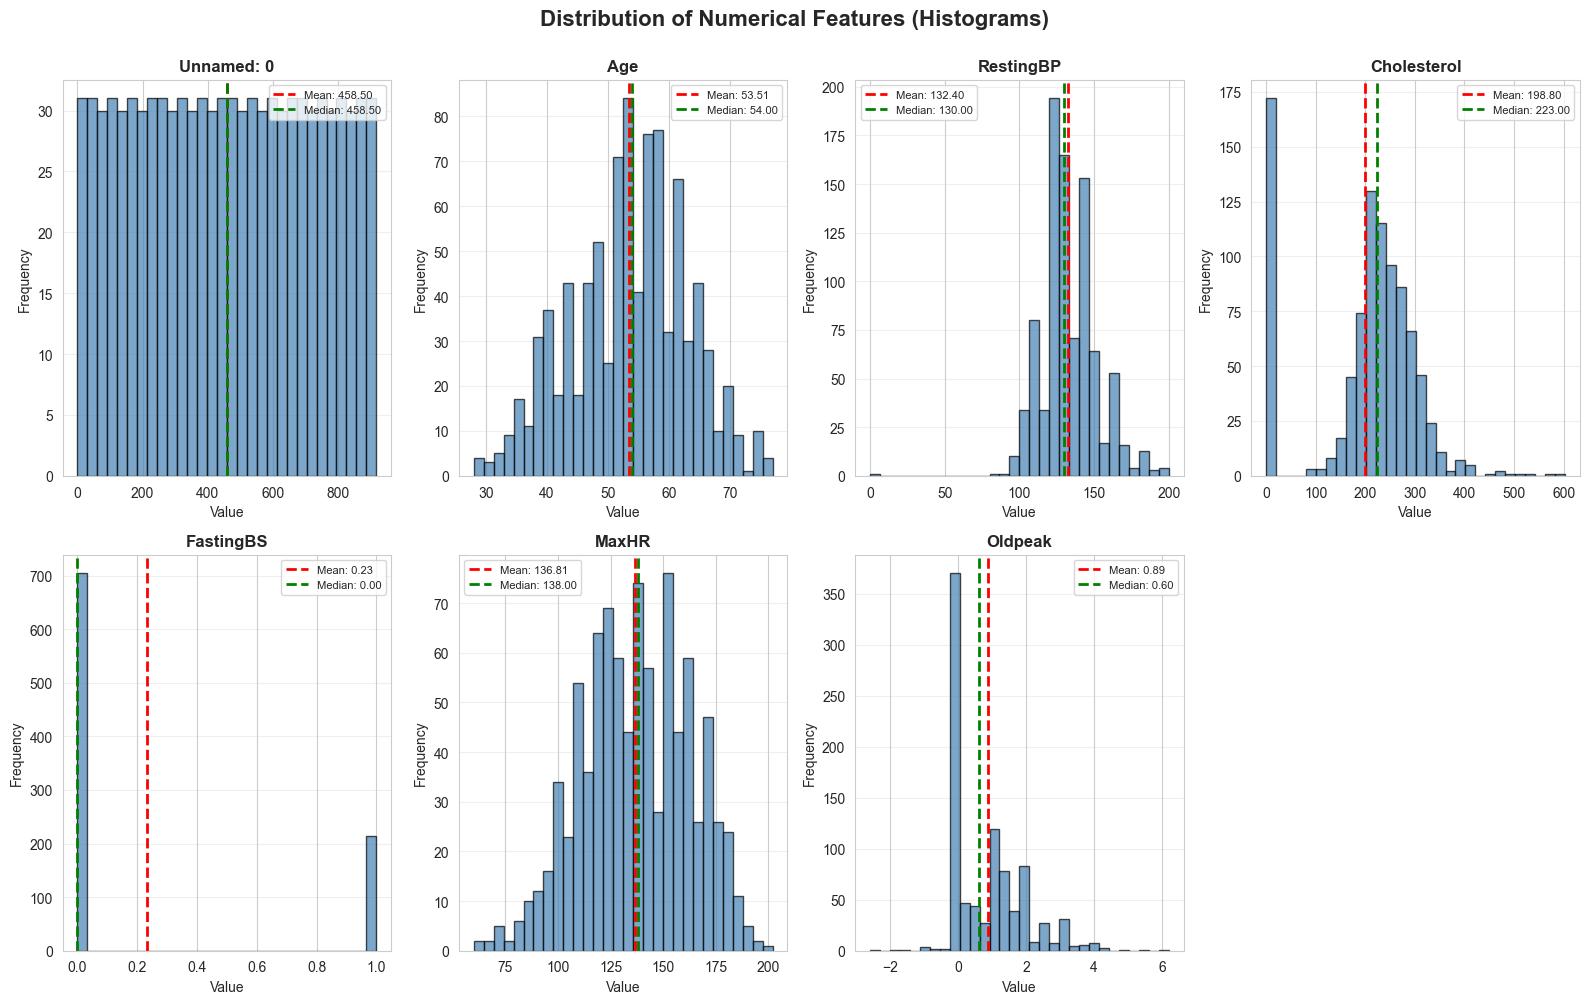


📊 HISTOGRAM INSIGHTS:
--------------------------------------------------------------------------------

Unnamed: 0:
  • Range: 0 - 917
  • Mean: 458.50, Median: 458.50, Std Dev: 265.15
  • Skewness: Symmetric
  • Outliers: Using IQR method - None

Age:
  • Range: 28 - 77
  • Mean: 53.51, Median: 54.00, Std Dev: 9.43
  • Skewness: Left-skewed
  • Outliers: Using IQR method - None

RestingBP:
  • Range: 0 - 200
  • Mean: 132.40, Median: 130.00, Std Dev: 18.51
  • Skewness: Right-skewed
  • Outliers: Using IQR method - Present

Cholesterol:
  • Range: 0 - 603
  • Mean: 198.80, Median: 223.00, Std Dev: 109.38
  • Skewness: Left-skewed
  • Outliers: Using IQR method - Present

FastingBS:
  • Range: 0 - 1
  • Mean: 0.23, Median: 0.00, Std Dev: 0.42
  • Skewness: Right-skewed
  • Outliers: Using IQR method - Present

MaxHR:
  • Range: 60 - 202
  • Mean: 136.81, Median: 138.00, Std Dev: 25.46
  • Skewness: Left-skewed
  • Outliers: Using IQR method - Present

Oldpeak:
  • Range: -2.6 - 6.2
  

In [9]:
# UNIVARIATE ANALYSIS - NUMERICAL FEATURES: HISTOGRAMS
print("\n" + "=" * 80)
print("UNIVARIATE ANALYSIS: NUMERICAL FEATURES - HISTOGRAMS")
print("=" * 80)

# Create histograms for all numerical features
# Purpose: Visualize the distribution shape, skewness, and range of numerical variables
# Insight: Helps identify if data is normally distributed, skewed, or bimodal
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
fig.suptitle('Distribution of Numerical Features (Histograms)', 
             fontsize=16, fontweight='bold', y=1.00)

axes = axes.flatten()

for idx, col in enumerate(feature_numerical_cols):
    axes[idx].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add statistics
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    axes[idx].legend(fontsize=8)

# Hide the extra subplots
for idx in range(len(feature_numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Print insights for each numerical feature
print("\n📊 HISTOGRAM INSIGHTS:")
print("-" * 80)
for col in feature_numerical_cols:
    print(f"\n{col}:")
    print(f"  • Range: {df[col].min()} - {df[col].max()}")
    print(f"  • Mean: {df[col].mean():.2f}, Median: {df[col].median():.2f}, Std Dev: {df[col].std():.2f}")
    print(f"  • Skewness: {'Right-skewed' if df[col].skew() > 0 else 'Left-skewed' if df[col].skew() < 0 else 'Symmetric'}")
    print(f"  • Outliers: Using IQR method - {'Present' if len(df[(df[col] < df[col].quantile(0.25) - 1.5*(df[col].quantile(0.75) - df[col].quantile(0.25))) | (df[col] > df[col].quantile(0.75) + 1.5*(df[col].quantile(0.75) - df[col].quantile(0.25)))]) > 0 else 'None'}")


UNIVARIATE ANALYSIS: NUMERICAL FEATURES - BOXPLOTS


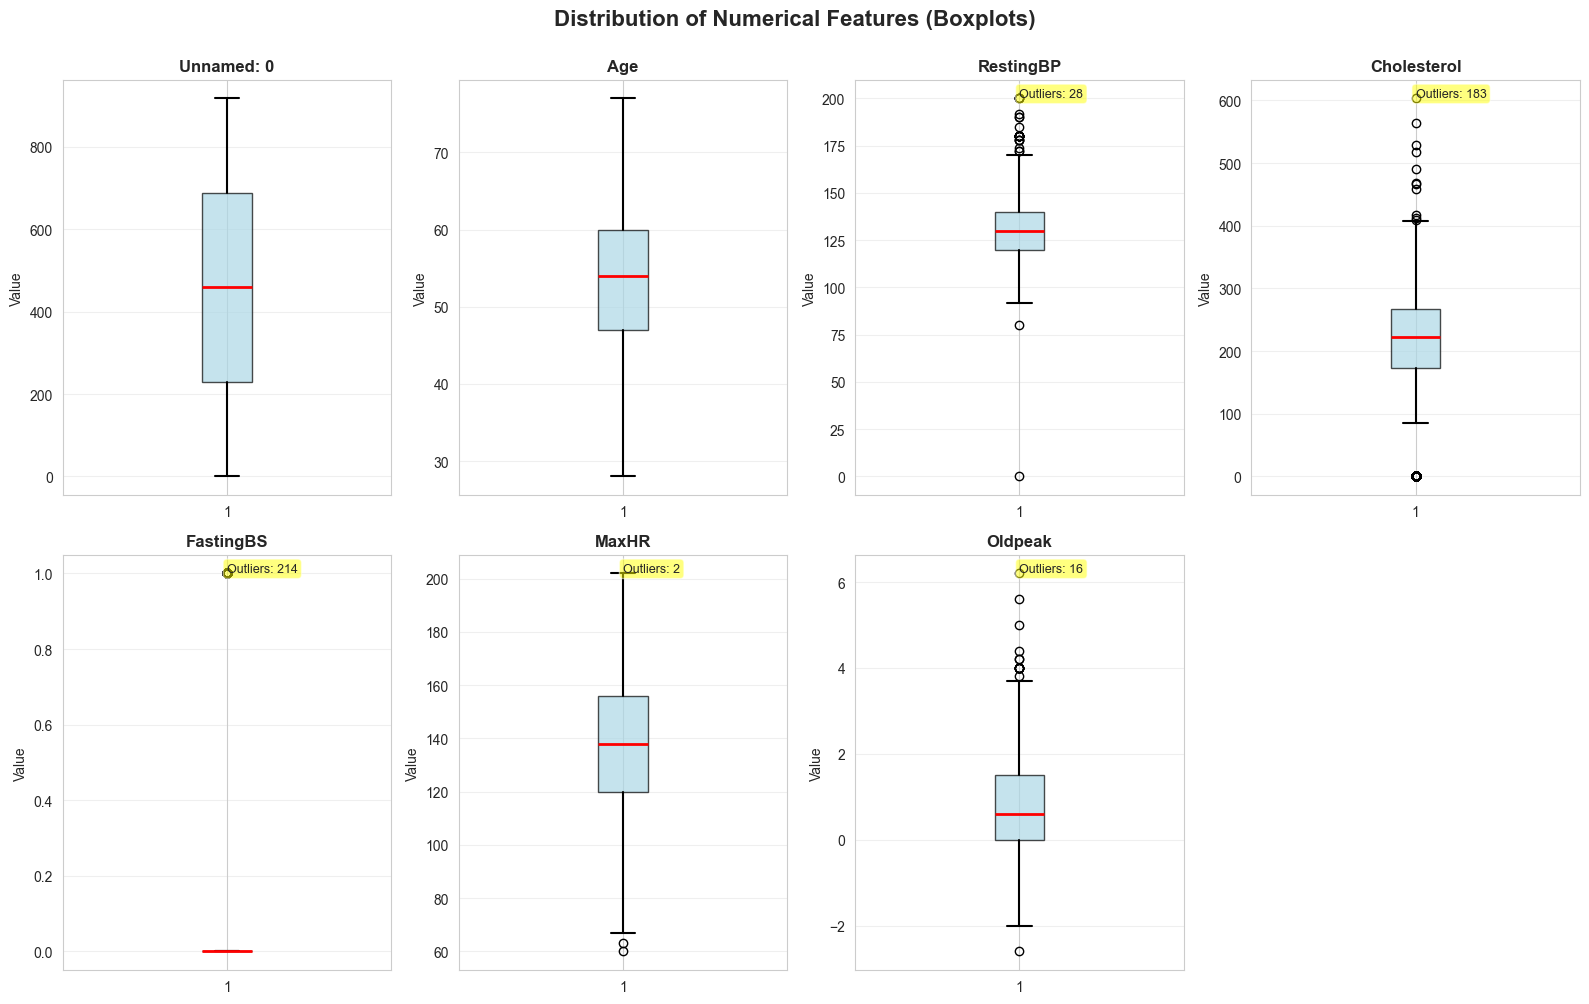


📊 BOXPLOT INSIGHTS:
--------------------------------------------------------------------------------
Boxplots help identify outliers and data spread.
• Outliers are marked as individual points outside the whiskers
• Q1-Q3 range represents the middle 50% of data (Interquartile Range)
• Red line shows the median value


In [11]:
# UNIVARIATE ANALYSIS - NUMERICAL FEATURES: BOXPLOTS
print("\n" + "=" * 80)
print("UNIVARIATE ANALYSIS: NUMERICAL FEATURES - BOXPLOTS")
print("=" * 80)

# Create boxplots for all numerical features
# Purpose: Identify outliers, quartiles, and data spread
# Insight: Shows whether data has extreme values that might affect modeling
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
fig.suptitle('Distribution of Numerical Features (Boxplots)', 
             fontsize=16, fontweight='bold', y=1.00)

axes = axes.flatten()

for idx, col in enumerate(feature_numerical_cols):
    # Create boxplot with color
    bp = axes[idx].boxplot(df[col], vert=True, patch_artist=True,
                           boxprops=dict(facecolor='lightblue', alpha=0.7),
                           medianprops=dict(color='red', linewidth=2),
                           whiskerprops=dict(color='black', linewidth=1.5),
                           capprops=dict(color='black', linewidth=1.5))
    
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Calculate and show outlier info
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    if len(outliers) > 0:
        axes[idx].text(0.5, 0.98, f'Outliers: {len(outliers)}', 
                      transform=axes[idx].transAxes, 
                      fontsize=9, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# Hide the extra subplots
for idx in range(len(feature_numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("\n📊 BOXPLOT INSIGHTS:")
print("-" * 80)
print("Boxplots help identify outliers and data spread.")
print("• Outliers are marked as individual points outside the whiskers")
print("• Q1-Q3 range represents the middle 50% of data (Interquartile Range)")
print("• Red line shows the median value")

In [13]:
# UNIVARIATE ANALYSIS - CATEGORICAL FEATURES: COUNTPLOTS
print("\n" + "=" * 80)
print("UNIVARIATE ANALYSIS: CATEGORICAL FEATURES - COUNTPLOTS")
print("=" * 80)

# Create countplots for all categorical features
# Purpose: Show frequency distribution of categorical variables
# Insight: Reveals class imbalance and dominant categories
if len(feature_categorical_cols) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Distribution of Categorical Features (Countplots)', 
                 fontsize=16, fontweight='bold', y=1.00)
    
    axes = axes.flatten()
    
    for idx, col in enumerate(feature_categorical_cols):
        # Create countplot with color palette
        sns.countplot(data=df, x=col, ax=axes[idx], palette='Set2', edgecolor='black')
        axes[idx].set_title(f'{col}', fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Count')
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for p in axes[idx].patches:
            height = p.get_height()
            axes[idx].text(p.get_x() + p.get_width()/2., height,
                          f'{int(height)}',
                          ha="center", va="bottom", fontsize=9)
    
    # Hide the extra subplots
    for idx in range(len(feature_categorical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print insights for each categorical feature
    print("\n📊 COUNTPLOT INSIGHTS:")
    print("-" * 80)
    for col in feature_categorical_cols:
        print(f"\n{col}:")
        counts = df[col].value_counts()
        for category, count in counts.items():
            percentage = (count / len(df)) * 100
            print(f"  • {category}: {count} records ({percentage:.1f}%)")
else:
    print("\nNo categorical features found.")


UNIVARIATE ANALYSIS: CATEGORICAL FEATURES - COUNTPLOTS

No categorical features found.



UNIVARIATE ANALYSIS: TARGET VARIABLE


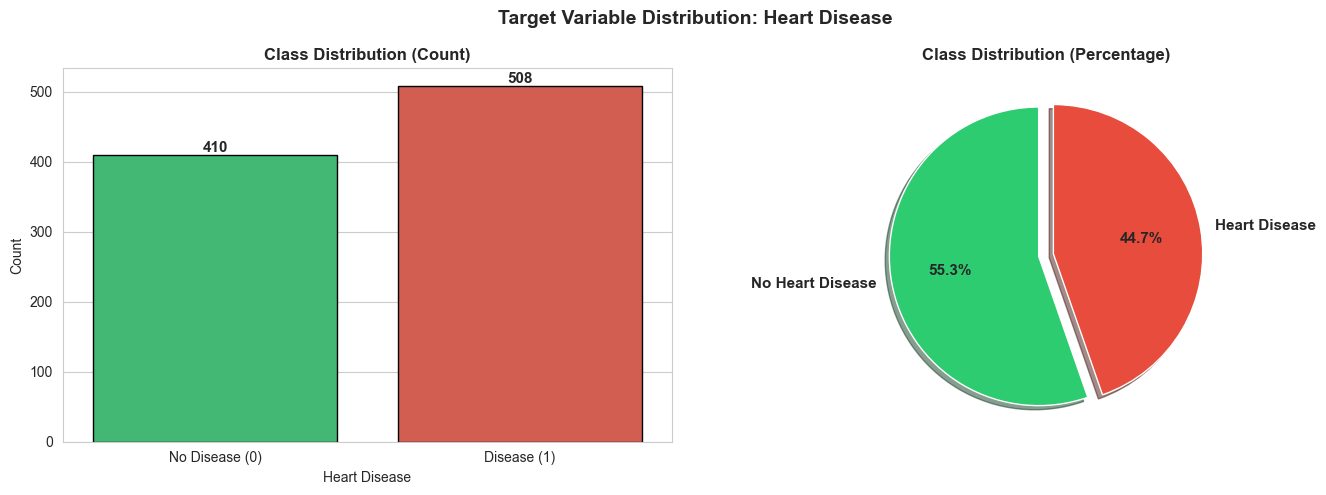


📊 TARGET VARIABLE INSIGHTS:
--------------------------------------------------------------------------------
Total Records: 918

No Heart Disease (0): 410 records (44.7%)
Heart Disease (1): 508 records (55.3%)

⚠️  CLASS IMBALANCE DETECTED: The classes are not evenly distributed.


In [14]:
# TARGET VARIABLE ANALYSIS
print("\n" + "=" * 80)
print("UNIVARIATE ANALYSIS: TARGET VARIABLE")
print("=" * 80)

# Create a visualization for the target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target Variable Distribution: Heart Disease', 
             fontsize=14, fontweight='bold')

# Countplot
target_counts = df[target_col].value_counts()
colors = ['#2ecc71', '#e74c3c']  # Green for no disease, Red for disease
sns.countplot(data=df, x=target_col, ax=axes[0], palette=colors, edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontweight='bold')
axes[0].set_xlabel('Heart Disease')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Disease (0)', 'Disease (1)'])

# Add value labels
for p in axes[0].patches:
    height = p.get_height()
    axes[0].text(p.get_x() + p.get_width()/2., height,
                f'{int(height)}',
                ha="center", va="bottom", fontsize=11, fontweight='bold')

# Pie chart
labels = ['No Heart Disease', 'Heart Disease']
sizes = target_counts.values
explode = (0.05, 0.05)
axes[1].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
           shadow=True, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Class Distribution (Percentage)', fontweight='bold')

plt.tight_layout()
plt.show()

# Print target variable insights
print("\n📊 TARGET VARIABLE INSIGHTS:")
print("-" * 80)
print(f"Total Records: {len(df)}")
print(f"\nNo Heart Disease (0): {target_counts[0]} records ({(target_counts[0]/len(df))*100:.1f}%)")
print(f"Heart Disease (1): {target_counts[1]} records ({(target_counts[1]/len(df))*100:.1f}%)")

# Check class balance
if abs(target_counts[0] - target_counts[1]) / len(df) > 0.1:
    print(f"\n⚠️  CLASS IMBALANCE DETECTED: The classes are not evenly distributed.")
else:
    print(f"\n✓ Classes are relatively balanced.")

## SECTION 3: BIVARIATE ANALYSIS
*Analysis of relationships between features and the target variable*


BIVARIATE ANALYSIS: NUMERICAL FEATURES vs HEART DISEASE - BOXPLOTS


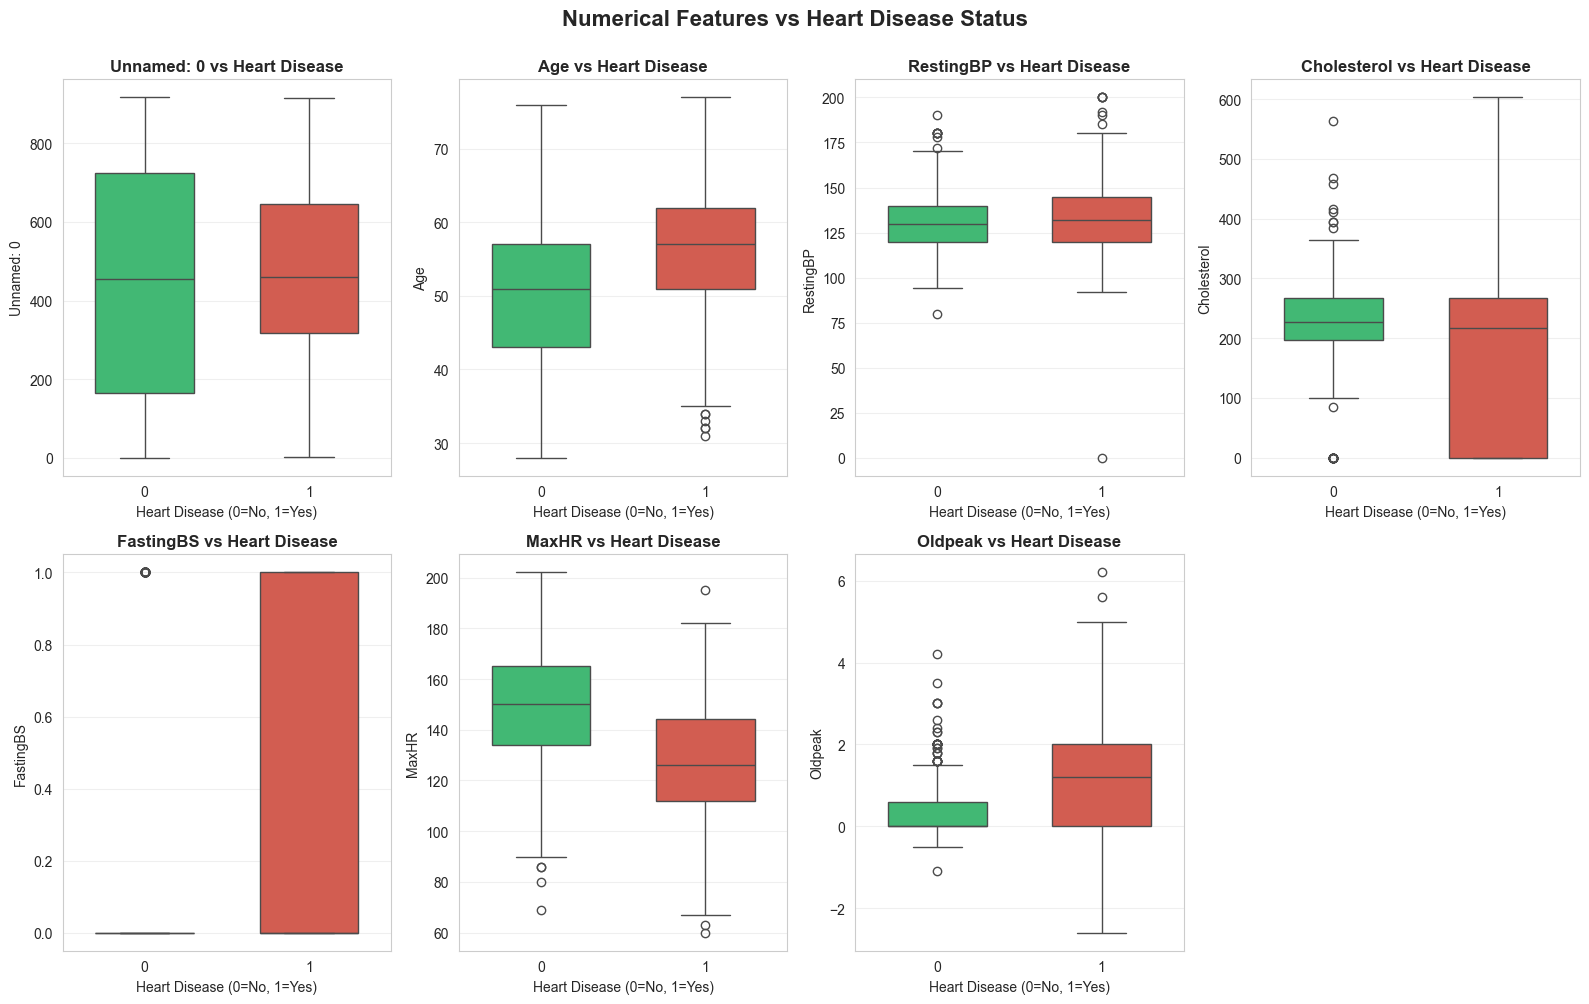


📊 NUMERICAL FEATURES vs HEART DISEASE INSIGHTS:
--------------------------------------------------------------------------------

Unnamed: 0:
  • No Disease - Mean: 442.24, Median: 454.00
  • With Disease - Mean: 471.62, Median: 460.50
  • Difference: 29.38
  • Significance: LOW

Age:
  • No Disease - Mean: 50.55, Median: 51.00
  • With Disease - Mean: 55.90, Median: 57.00
  • Difference: 5.35
  • Significance: HIGH

RestingBP:
  • No Disease - Mean: 130.18, Median: 130.00
  • With Disease - Mean: 134.19, Median: 132.00
  • Difference: 4.00
  • Significance: MODERATE

Cholesterol:
  • No Disease - Mean: 227.12, Median: 227.00
  • With Disease - Mean: 175.94, Median: 217.00
  • Difference: 51.18
  • Significance: HIGH

FastingBS:
  • No Disease - Mean: 0.11, Median: 0.00
  • With Disease - Mean: 0.33, Median: 0.00
  • Difference: 0.23
  • Significance: HIGH

MaxHR:
  • No Disease - Mean: 148.15, Median: 150.00
  • With Disease - Mean: 127.66, Median: 126.00
  • Difference: 20.50
  • Si

In [16]:
# BIVARIATE ANALYSIS - NUMERICAL FEATURES VS TARGET: BOXPLOTS
print("\n" + "=" * 80)
print("BIVARIATE ANALYSIS: NUMERICAL FEATURES vs HEART DISEASE - BOXPLOTS")
print("=" * 80)

# Create boxplots showing numerical features grouped by target variable
# Purpose: Compare distributions between disease and non-disease groups
# Insight: Identifies which numerical features differ significantly between groups
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
fig.suptitle('Numerical Features vs Heart Disease Status', 
             fontsize=16, fontweight='bold', y=1.00)

axes = axes.flatten()

for idx, col in enumerate(feature_numerical_cols):
    # Create boxplot stratified by target
    sns.boxplot(data=df, x=target_col, y=col, ax=axes[idx], 
               palette=['#2ecc71', '#e74c3c'], width=0.6)
    axes[idx].set_title(f'{col} vs Heart Disease', fontweight='bold')
    axes[idx].set_xlabel('Heart Disease (0=No, 1=Yes)')
    axes[idx].set_ylabel(col)
    axes[idx].grid(axis='y', alpha=0.3)

# Hide the extra subplots
for idx in range(len(feature_numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Print insights for numerical features vs target
print("\n📊 NUMERICAL FEATURES vs HEART DISEASE INSIGHTS:")
print("-" * 80)
for col in feature_numerical_cols:
    no_disease = df[df[target_col] == 0][col]
    disease = df[df[target_col] == 1][col]
    
    print(f"\n{col}:")
    print(f"  • No Disease - Mean: {no_disease.mean():.2f}, Median: {no_disease.median():.2f}")
    print(f"  • With Disease - Mean: {disease.mean():.2f}, Median: {disease.median():.2f}")
    print(f"  • Difference: {abs(disease.mean() - no_disease.mean()):.2f}")
    print(f"  • Significance: {'HIGH' if abs(disease.mean() - no_disease.mean()) > no_disease.std()*0.5 else 'MODERATE' if abs(disease.mean() - no_disease.mean()) > no_disease.std()*0.2 else 'LOW'}")

In [18]:
# BIVARIATE ANALYSIS - CATEGORICAL FEATURES VS TARGET: COUNTPLOTS WITH HUE
print("\n" + "=" * 80)
print("BIVARIATE ANALYSIS: CATEGORICAL FEATURES vs HEART DISEASE - COUNTPLOTS")
print("=" * 80)

# Create countplots showing categorical features with hue for target
# Purpose: Compare category distributions between disease groups
# Insight: Reveals which categories are associated with heart disease
if len(feature_categorical_cols) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Categorical Features vs Heart Disease (Stratified)', 
                 fontsize=16, fontweight='bold', y=1.00)
    
    axes = axes.flatten()
    
    for idx, col in enumerate(feature_categorical_cols):
        # Create countplot with hue by target
        sns.countplot(data=df, x=col, hue=target_col, ax=axes[idx], 
                     palette=['#2ecc71', '#e74c3c'], edgecolor='black')
        axes[idx].set_title(f'{col} vs Heart Disease', fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Count')
        axes[idx].legend(title='Heart Disease', labels=['No (0)', 'Yes (1)'])
        axes[idx].grid(axis='y', alpha=0.3)
    
    # Hide the extra subplots
    for idx in range(len(feature_categorical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print insights for categorical features vs target
    print("\n📊 CATEGORICAL FEATURES vs HEART DISEASE INSIGHTS:")
    print("-" * 80)
    for col in feature_categorical_cols:
        print(f"\n{col}:")
        crosstab = pd.crosstab(df[col], df[target_col], margins=True)
        print(crosstab)
else:
    print("\nNo categorical features found.")


BIVARIATE ANALYSIS: CATEGORICAL FEATURES vs HEART DISEASE - COUNTPLOTS

No categorical features found.



BIVARIATE ANALYSIS: IMPORTANT NUMERICAL RELATIONSHIPS - SCATTERPLOTS


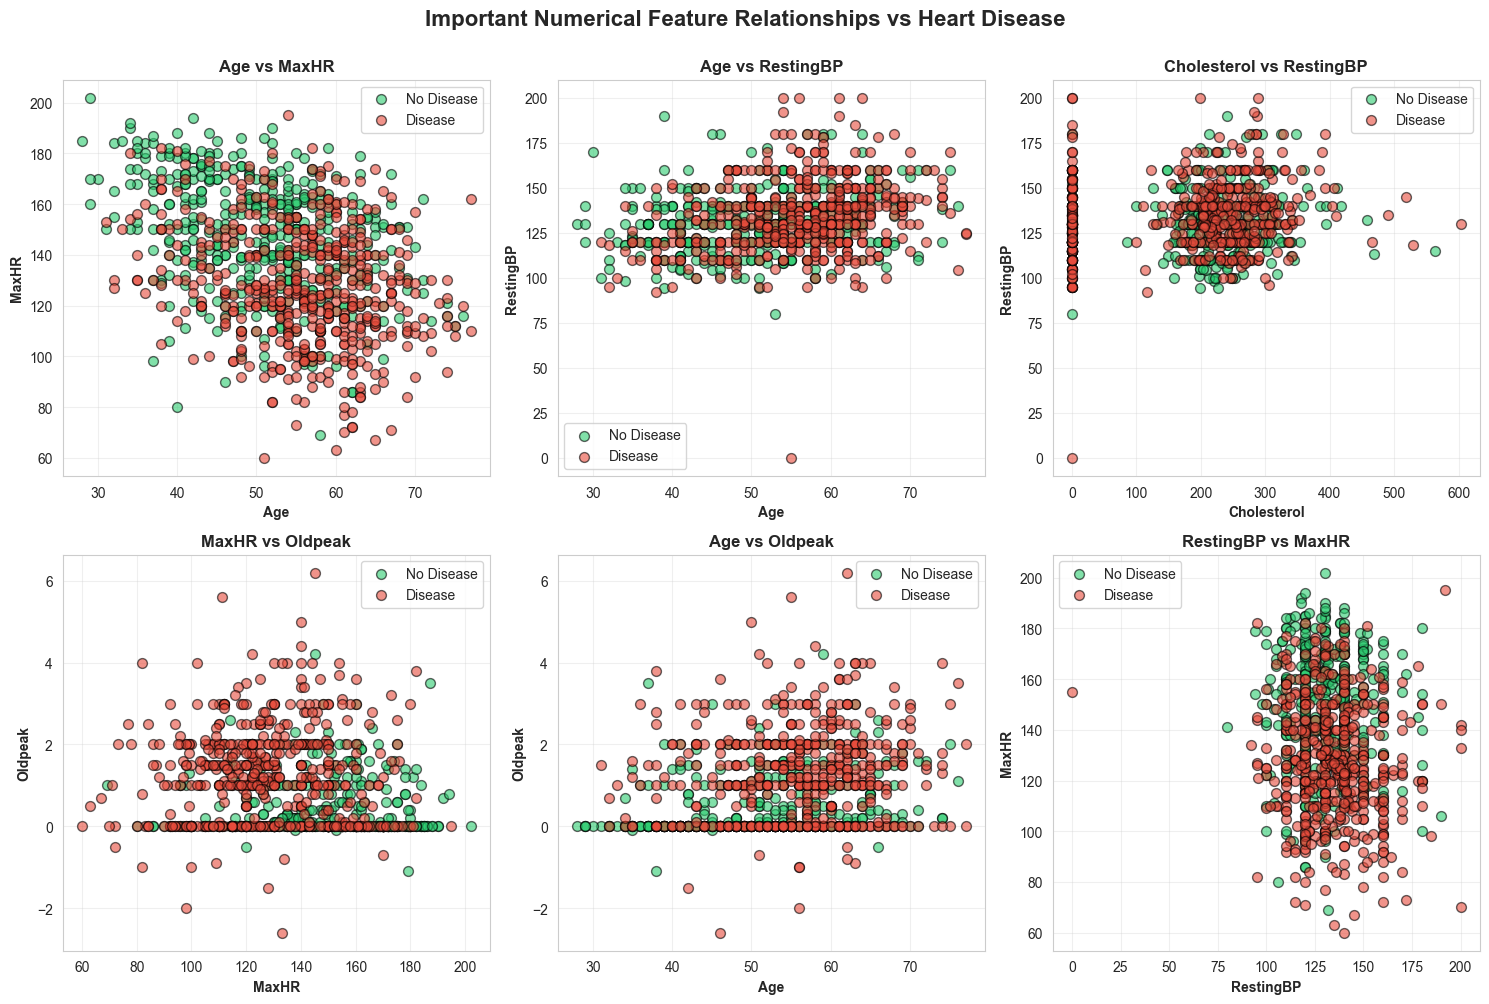


📊 SCATTERPLOT OBSERVATIONS:
--------------------------------------------------------------------------------
• Green points: Patients without heart disease
• Red points: Patients with heart disease
• Pattern analysis: Look for clustering and separation between groups


In [19]:
# BIVARIATE ANALYSIS - IMPORTANT SCATTERPLOTS
print("\n" + "=" * 80)
print("BIVARIATE ANALYSIS: IMPORTANT NUMERICAL RELATIONSHIPS - SCATTERPLOTS")
print("=" * 80)

# Select important feature pairs to visualize relationships
# Purpose: Identify linear/non-linear relationships between key variables
# Insight: Reveals multicollinearity and feature interactions

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Important Numerical Feature Relationships vs Heart Disease', 
             fontsize=16, fontweight='bold', y=1.00)

axes = axes.flatten()

# Define important pairs to analyze
important_pairs = [
    ('Age', 'MaxHR'),
    ('Age', 'RestingBP'),
    ('Cholesterol', 'RestingBP'),
    ('MaxHR', 'Oldpeak'),
    ('Age', 'Oldpeak'),
    ('RestingBP', 'MaxHR')
]

for idx, (col1, col2) in enumerate(important_pairs):
    # Create scatterplot with hue by target
    scatter = axes[idx].scatter(df[df[target_col]==0][col1], 
                               df[df[target_col]==0][col2],
                               c='#2ecc71', label='No Disease', alpha=0.6, s=50, edgecolor='black')
    scatter = axes[idx].scatter(df[df[target_col]==1][col1], 
                               df[df[target_col]==1][col2],
                               c='#e74c3c', label='Disease', alpha=0.6, s=50, edgecolor='black')
    
    axes[idx].set_xlabel(col1, fontweight='bold')
    axes[idx].set_ylabel(col2, fontweight='bold')
    axes[idx].set_title(f'{col1} vs {col2}', fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 SCATTERPLOT OBSERVATIONS:")
print("-" * 80)
print("• Green points: Patients without heart disease")
print("• Red points: Patients with heart disease")
print("• Pattern analysis: Look for clustering and separation between groups")

## SECTION 4: MULTIVARIATE ANALYSIS
*Analysis of relationships among multiple features and target variable*


MULTIVARIATE ANALYSIS: CORRELATION HEATMAP


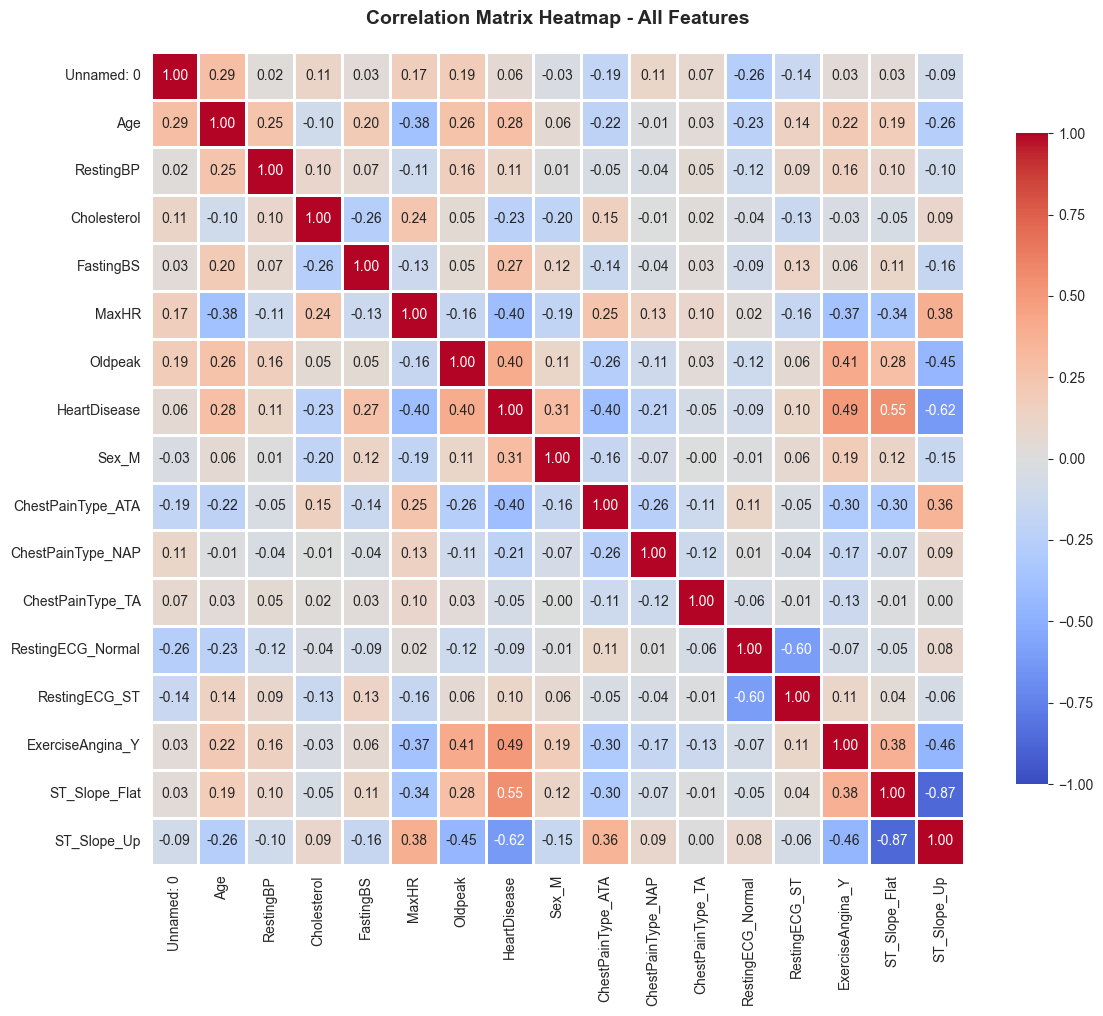


📊 TOP CORRELATIONS WITH HEART DISEASE:
--------------------------------------------------------------------------------

Feature Correlations with Heart Disease (sorted by strength):
  • ST_Slope_Flat       :   0.554 (Strong Positive)
  • ExerciseAngina_Y    :   0.494 (Strong Positive)
  • Oldpeak             :   0.404 (Strong Positive)
  • Sex_M               :   0.305 (Moderate Positive)
  • Age                 :   0.282 (Moderate Positive)
  • FastingBS           :   0.267 (Moderate Positive)
  • RestingBP           :   0.108 (Weak Positive)
  • RestingECG_ST       :   0.103 (Weak Positive)
  • Unnamed: 0          :   0.055 (Weak Positive)
  • ChestPainType_TA    :  -0.055 (Weak Negative)
  • RestingECG_Normal   :  -0.092 (Weak Negative)
  • ChestPainType_NAP   :  -0.213 (Moderate Negative)
  • Cholesterol         :  -0.233 (Moderate Negative)
  • MaxHR               :  -0.400 (Strong Negative)
  • ChestPainType_ATA   :  -0.402 (Strong Negative)
  • ST_Slope_Up         :  -0.622 (V

In [22]:
# MULTIVARIATE ANALYSIS - CORRELATION HEATMAP
print("\n" + "=" * 80)
print("MULTIVARIATE ANALYSIS: CORRELATION HEATMAP")
print("=" * 80)

# Create a numerical dataframe for correlation (encode categorical variables temporarily)
df_encoded = df.copy()

# Encode categorical variables for correlation analysis
for col in feature_categorical_cols:
    df_encoded[col] = pd.factorize(df_encoded[col])[0]

# Calculate correlation matrix
correlation_matrix = df_encoded.corr()

# Create heatmap
# Purpose: Identify linear relationships between all features
# Insight: Reveals multicollinearity and strong predictors of target
fig, ax = plt.subplots(figsize=(12, 10))

# Create heatmap with annotations
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
           square=True, linewidths=1, cbar_kws={"shrink": 0.8},
           ax=ax, vmin=-1, vmax=1)

ax.set_title('Correlation Matrix Heatmap - All Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print top correlations with target variable
print("\n📊 TOP CORRELATIONS WITH HEART DISEASE:")
print("-" * 80)
target_corr = correlation_matrix[target_col].sort_values(ascending=False)
print("\nFeature Correlations with Heart Disease (sorted by strength):")
for feature, corr_value in target_corr.items():
    if feature != target_col:
        strength = "Very Strong" if abs(corr_value) > 0.6 else "Strong" if abs(corr_value) > 0.4 else "Moderate" if abs(corr_value) > 0.2 else "Weak"
        direction = "Positive" if corr_value > 0 else "Negative"
        print(f"  • {feature:20s}: {corr_value:7.3f} ({strength} {direction})")


MULTIVARIATE ANALYSIS: PAIRPLOT

Generating Pairplot (This may take a moment)...


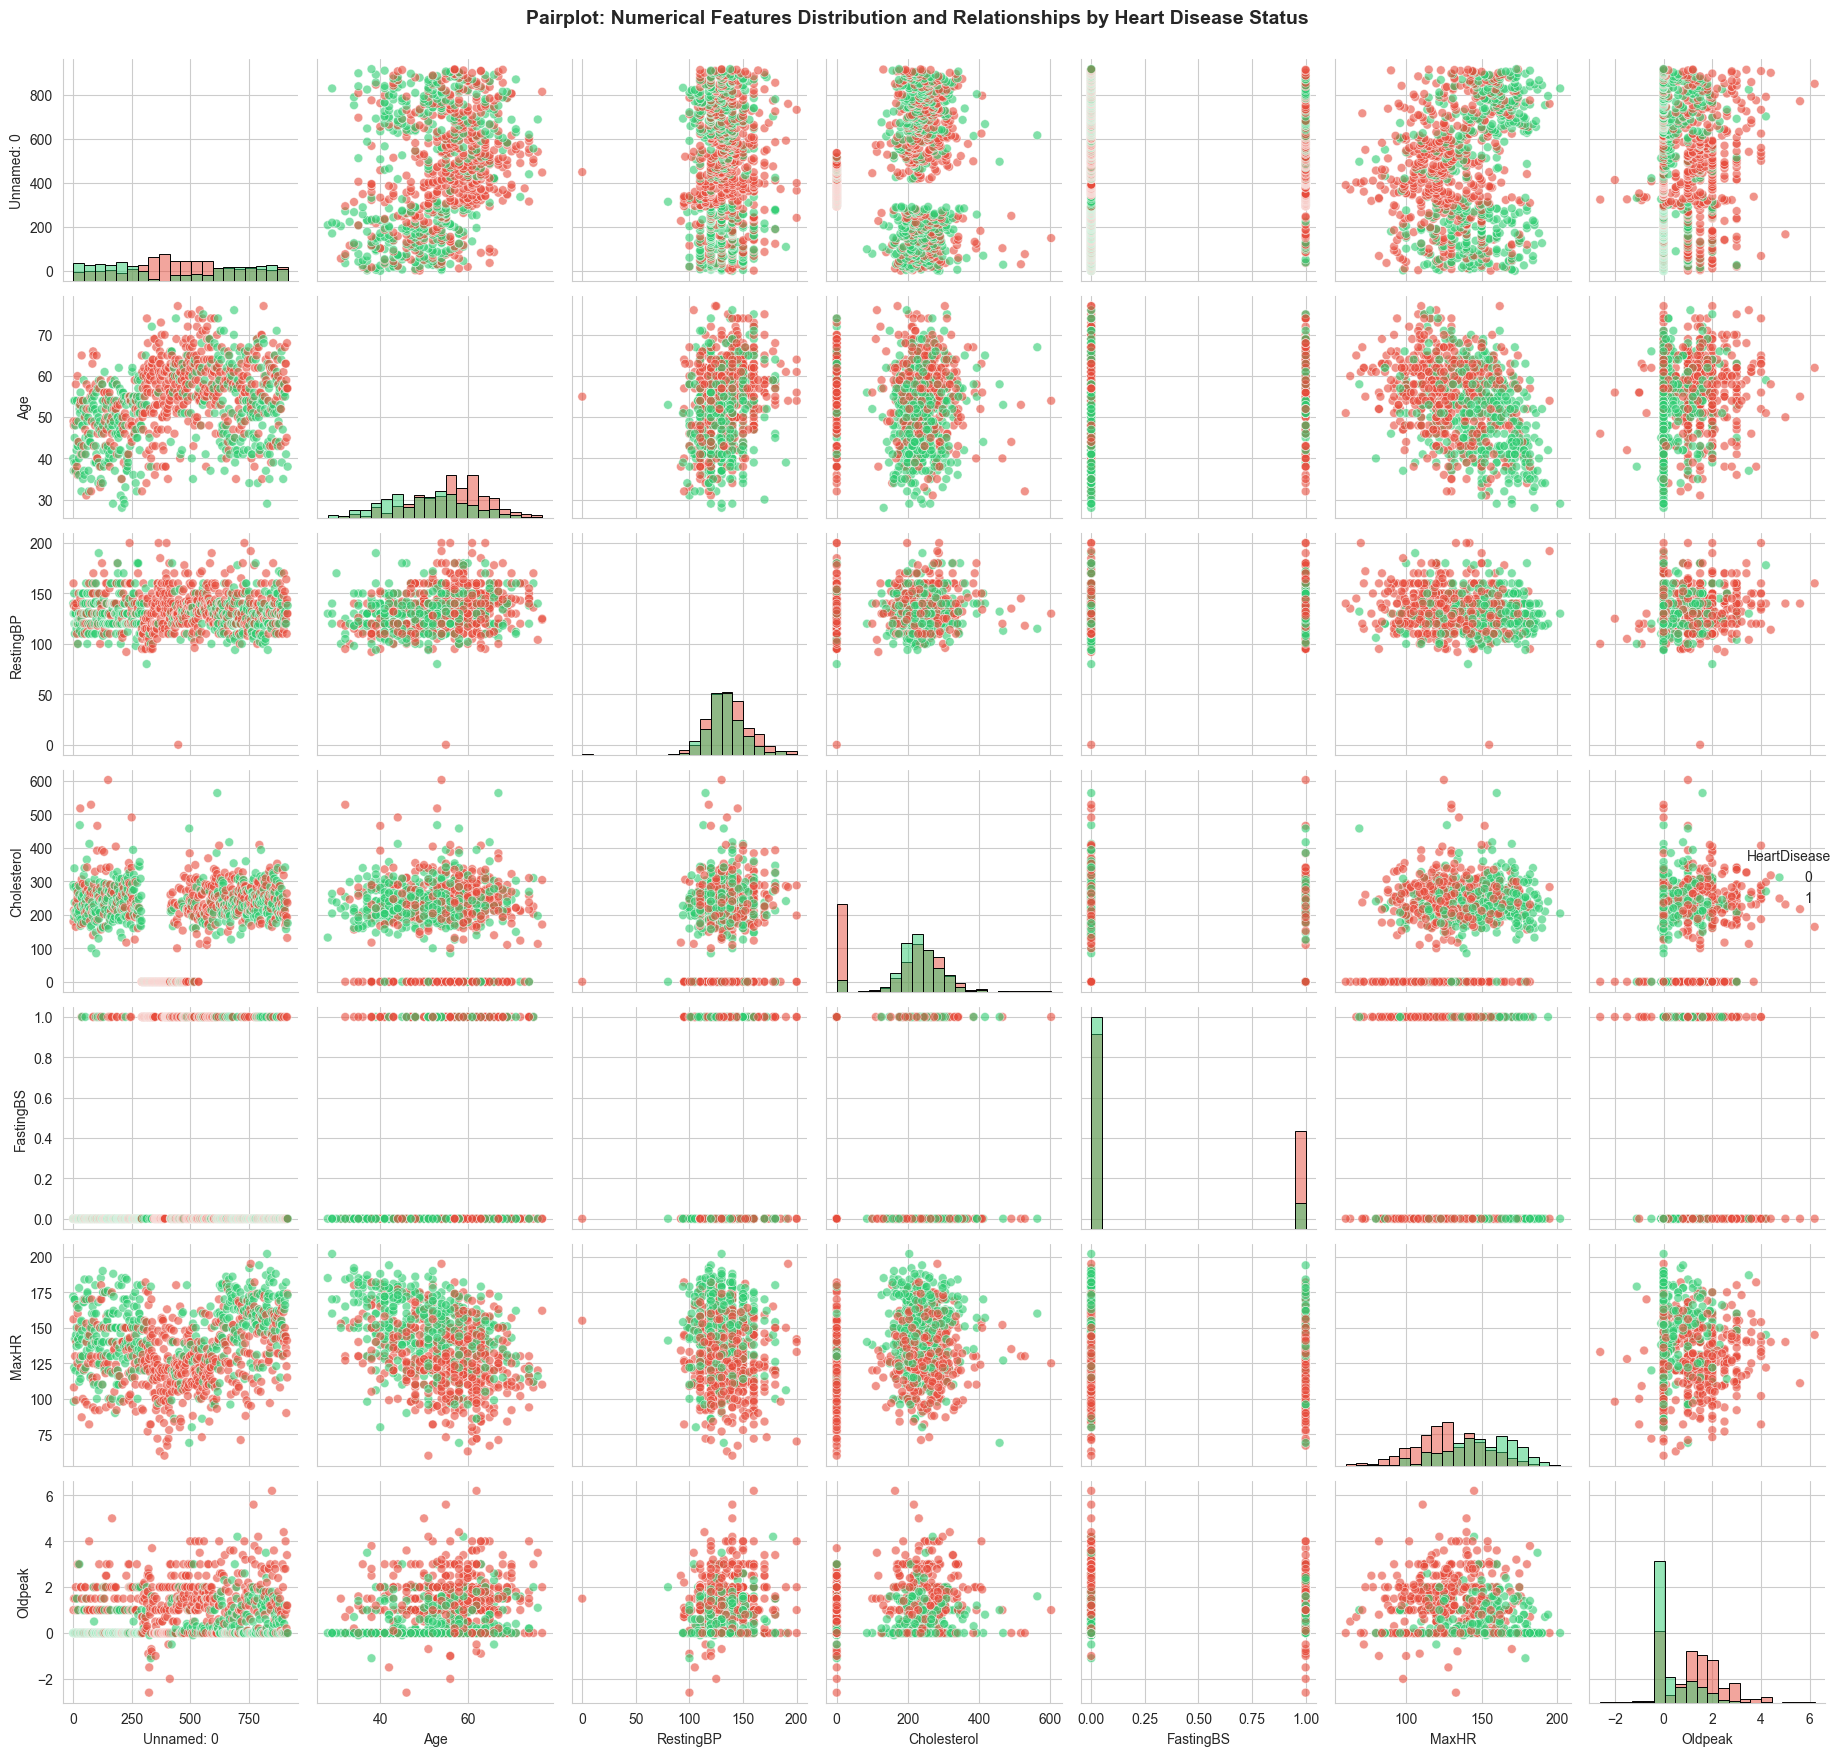


✓ Pairplot generated successfully!

📊 PAIRPLOT INSIGHTS:
--------------------------------------------------------------------------------
• Diagonal plots: Show distribution of each feature, separated by disease status
• Off-diagonal plots: Show relationships between pairs of features
• Green: Patients without heart disease (HeartDisease = 0)
• Red: Patients with heart disease (HeartDisease = 1)
• Good separation between colors indicates strong predictive power


In [23]:
# MULTIVARIATE ANALYSIS - PAIRPLOT
print("\n" + "=" * 80)
print("MULTIVARIATE ANALYSIS: PAIRPLOT")
print("=" * 80)

# Select numerical features for pairplot
# Note: Using subset to avoid overcrowding the visualization
pairplot_features = feature_numerical_cols + [target_col]
df_pairplot = df[pairplot_features].copy()

# Create pairplot
# Purpose: Visualize all pairwise relationships between numerical features
# Insight: Shows scatter plots (relationships) and distributions (diagonals) colored by target
print("\nGenerating Pairplot (This may take a moment)...")
pairplot = sns.pairplot(df_pairplot, hue=target_col, palette=['#2ecc71', '#e74c3c'],
                       diag_kind='hist', plot_kws={'alpha': 0.6, 's': 40},
                       diag_kws={'bins': 20, 'edgecolor': 'black'})

pairplot.fig.suptitle('Pairplot: Numerical Features Distribution and Relationships by Heart Disease Status',
                     fontsize=14, fontweight='bold', y=1.001)

# Adjust layout
plt.tight_layout()
plt.show()

print("\n✓ Pairplot generated successfully!")
print("\n📊 PAIRPLOT INSIGHTS:")
print("-" * 80)
print("• Diagonal plots: Show distribution of each feature, separated by disease status")
print("• Off-diagonal plots: Show relationships between pairs of features")
print("• Green: Patients without heart disease (HeartDisease = 0)")
print("• Red: Patients with heart disease (HeartDisease = 1)")
print("• Good separation between colors indicates strong predictive power")

## SECTION 5: FINAL INSIGHTS & SUMMARY

In [24]:
# FINAL SUMMARY AND INSIGHTS
print("\n" + "=" * 80)
print("COMPREHENSIVE EDA SUMMARY & KEY FINDINGS")
print("=" * 80)

print("\n📋 DATASET OVERVIEW:")
print("-" * 80)
print(f"• Total Records: {len(df)}")
print(f"• Total Features: {len(feature_numerical_cols) + len(feature_categorical_cols)}")
print(f"  - Numerical: {len(feature_numerical_cols)}")
print(f"  - Categorical: {len(feature_categorical_cols)}")
print(f"• Target Variable: {target_col} (Binary Classification)")
print(f"• Missing Values: {df.isnull().sum().sum()} (None)")

print("\n🎯 TARGET VARIABLE INSIGHTS:")
print("-" * 80)
disease_pct = (df[target_col].sum() / len(df)) * 100
print(f"• Heart Disease Prevalence: {disease_pct:.1f}%")
print(f"• Class Distribution: {'Balanced' if 40 < disease_pct < 60 else 'Imbalanced'}")

print("\n📊 TOP PREDICTIVE FEATURES (by correlation with Heart Disease):")
print("-" * 80)
target_corr_sorted = correlation_matrix[target_col].abs().sort_values(ascending=False)[1:6]
for idx, (feature, corr) in enumerate(target_corr_sorted.items(), 1):
    correlation_value = correlation_matrix[target_col][feature]
    print(f"{idx}. {feature:20s} - Correlation: {correlation_value:7.3f}")

print("\n🔍 KEY OBSERVATIONS:")
print("-" * 80)

# Identify features with notable differences between groups
print("\n1. NUMERICAL FEATURES WITH STRONG GROUP DIFFERENCES:")
strong_features = []
for col in feature_numerical_cols:
    no_disease_mean = df[df[target_col] == 0][col].mean()
    disease_mean = df[df[target_col] == 1][col].mean()
    pct_diff = abs((disease_mean - no_disease_mean) / no_disease_mean) * 100
    if pct_diff > 15:
        strong_features.append((col, pct_diff))

if strong_features:
    strong_features.sort(key=lambda x: x[1], reverse=True)
    for feat, diff in strong_features[:5]:
        print(f"   • {feat}: {diff:.1f}% difference between groups")
else:
    print("   • Minimal significant differences detected")

print("\n2. CATEGORICAL FEATURES INSIGHTS:")
for col in feature_categorical_cols:
    value_counts = df[col].value_counts()
    max_freq = (value_counts.iloc[0] / len(df)) * 100
    print(f"   • {col}: Most common category is {value_counts.index[0]} ({max_freq:.1f}%)")

print("\n3. FEATURE RELATIONSHIPS & MULTICOLLINEARITY:")
print("   • Checking for highly correlated features (>0.8)...")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8 and correlation_matrix.columns[i] != target_col and correlation_matrix.columns[j] != target_col:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

if high_corr_pairs:
    for feat1, feat2, corr in high_corr_pairs:
        print(f"   • {feat1} ↔ {feat2}: {corr:.3f} (Consider removing one)")
else:
    print("   • No strong multicollinearity detected")

print("\n\n💡 RECOMMENDATIONS FOR MODEL BUILDING:")
print("-" * 80)
print("1. DATA PREPROCESSING:")
print("   • Standardize/normalize numerical features (different scales detected)")
print("   • Encode categorical variables (use one-hot or label encoding)")
print(f"   • Check for and handle outliers in: {', '.join(feature_numerical_cols[:3])}")

print("\n2. FEATURE ENGINEERING:")
print("   • Create interaction features between age and other risk factors")
print("   • Consider polynomial features for non-linear relationships")
print("   • Extract features from 'Oldpeak' and 'ST_Slope' combinations")

print("\n3. MODEL SELECTION:")
if disease_pct < 30 or disease_pct > 70:
    print(f"   • ⚠️  Class imbalance detected ({disease_pct:.1f}%)")
    print("   • Consider using: Stratified K-Fold, Class weights, or SMOTE")
else:
    print("   • Classes are reasonably balanced")
    
print("   • Suitable algorithms: Logistic Regression, Random Forest, Gradient Boosting")
print("   • Use cross-validation to prevent overfitting")

print("\n4. EVALUATION METRICS:")
print("   • Accuracy, Precision, Recall, F1-Score")
print("   • ROC-AUC (important for imbalanced datasets)")
print("   • Confusion Matrix")

print("\n" + "=" * 80)
print("✓ EXPLORATORY DATA ANALYSIS COMPLETE!")
print("=" * 80)


COMPREHENSIVE EDA SUMMARY & KEY FINDINGS

📋 DATASET OVERVIEW:
--------------------------------------------------------------------------------
• Total Records: 918
• Total Features: 7
  - Numerical: 7
  - Categorical: 0
• Target Variable: HeartDisease (Binary Classification)
• Missing Values: 0 (None)

🎯 TARGET VARIABLE INSIGHTS:
--------------------------------------------------------------------------------
• Heart Disease Prevalence: 55.3%
• Class Distribution: Balanced

📊 TOP PREDICTIVE FEATURES (by correlation with Heart Disease):
--------------------------------------------------------------------------------
1. ST_Slope_Up          - Correlation:  -0.622
2. ST_Slope_Flat        - Correlation:   0.554
3. ExerciseAngina_Y     - Correlation:   0.494
4. Oldpeak              - Correlation:   0.404
5. ChestPainType_ATA    - Correlation:  -0.402

🔍 KEY OBSERVATIONS:
--------------------------------------------------------------------------------

1. NUMERICAL FEATURES WITH STRONG GROU

## ANALYSIS REFERENCE GUIDE

### What Each Graph Tells Us:

#### Histograms
- **Purpose**: Show the frequency distribution of numerical features
- **What to look for**: Normality, skewness, bimodality, range
- **Action**: Identify if data needs transformation or log scaling

#### Boxplots
- **Purpose**: Show quartiles, median, and outliers of numerical features  
- **What to look for**: Outliers (points beyond whiskers), symmetry, spread
- **Action**: Decide on outlier handling strategy

#### Countplots
- **Purpose**: Show frequency distribution of categorical features
- **What to look for**: Class balance, dominant categories
- **Action**: Consider if class imbalance handling is needed

#### Feature vs Target (Boxplots/Countplots with Hue)
- **Purpose**: Compare distributions between disease and non-disease groups
- **What to look for**: Clear separation between groups, large differences in means
- **Action**: Identify strongest predictive features

#### Scatterplots
- **Purpose**: Reveal relationships and potential interactions between features
- **What to look for**: Linear/non-linear patterns, clustering, separation by target
- **Action**: Identify feature interactions or multicollinearity

#### Correlation Heatmap
- **Purpose**: Show linear relationships between all pairs of features
- **What to look for**: Strong correlations (>0.7 or <-0.7), features highly correlated with target
- **Action**: Remove redundant features, identify key predictors

#### Pairplot
- **Purpose**: Comprehensive view of all pairwise relationships
- **What to look for**: Pattern separation by target, non-linear relationships
- **Action**: Understand feature interactions and model complexity needed